# 📈 Modelado - Regresión y Clasificación

## 🎯 1. Objetivo del notebook

En este notebook se entrenan y evalúan los modelos de Machine Learning solicitados para el proyecto.

A partir del dataset limpio generado en el notebook de preprocesamiento, se trabajará con dos objetivos diferentes:

- Un modelo de regresión lineal para predecir la variable `nota_final`.
- Un modelo de regresión logística para predecir la variable `aprobado`.

El objetivo es preparar los datos de forma adecuada, entrenar ambos modelos y evaluar su rendimiento utilizando métricas apropiadas para cada tipo de problema.

En el caso de la regresión, se analizarán métricas como MAE, RMSE y R².  
En el caso de la clasificación, se tendrá en cuenta el desequilibrio observado en la variable `aprobado`, por lo que no se evaluará el modelo únicamente con accuracy.

## 2. Importación de librerías 

In [1]:
# Importación de librerías principales
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Herramientas de preparación de datos
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

# Métricas para regresión
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Métricas para clasificación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Configuración de visualización
pd.set_option("display.max_columns", None)

### Importación de librerías

Se importan las librerías necesarias para la fase de modelado.

En este notebook se utilizan herramientas de `scikit-learn` para dividir los datos en entrenamiento y prueba, aplicar transformaciones a las variables, crear pipelines y entrenar los modelos de regresión lineal y regresión logística.

También se importan métricas específicas para evaluar cada tipo de problema: métricas de error para regresión y métricas de clasificación para el modelo logístico.

## 3. Carga de datos

In [2]:
# Definición de la ruta del dataset procesado
ruta_processed = Path("../Data/processed/dataset_estudiantes_limpio.csv")

# Carga del dataset limpio
df_model = pd.read_csv(ruta_processed)

# Mostramos las primeras filas
df_model.head()


,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado
0,8.957476,48.830601,86.640182,6.675694,25,Fácil,Sí,Tarde,Lectura/Escritura,84.4,1
1,11.042524,80.825707,83.449655,4.616844,18,Difícil,No,Tarde,Desconocido,72.0,1
2,4.510776,90.383694,74.623607,7.755246,25,Fácil,No,Mañana,Lectura/Escritura,80.0,1
3,6.647213,81.878257,82.849841,8.592826,23,Fácil,No,Desconocido,Visual,78.2,1
4,1.000000,66.254179,54.539935,6.671840,21,Medio,No,Desconocido,Auditivo,66.0,1


### Carga del dataset procesado

Se carga el dataset limpio generado en el notebook de preprocesamiento.

A diferencia del análisis exploratorio, en esta fase ya se trabaja con una versión sin valores nulos y preparada para continuar con el modelado.

El objetivo es utilizar este dataset como base para entrenar los modelos de regresión y clasificación.

## 4. Revisión del dataset

Aunque ya lo revisamos antes, aquí hacemos una comprobación rápida para asegurarnos de que todo está correcto antes de preparar los modelos.

### 4.1 Dimensiones del dataset

In [3]:
# Dimensiones del dataset procesado
print(f"El dataset procesado contiene {df_model.shape[0]} filas y {df_model.shape[1]} columnas.")


El dataset procesado contiene 1000 filas y 11 columnas.


### 4.2 Información general

In [4]:
# Información general del dataset procesado
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   horas_estudio_semanal      1000 non-null   float64
 1   nota_anterior              1000 non-null   float64
 2   tasa_asistencia            1000 non-null   float64
 3   horas_sueno                1000 non-null   float64
 4   edad                       1000 non-null   int64  
 5   nivel_dificultad           1000 non-null   object 
 6   tiene_tutor                1000 non-null   object 
 7   horario_estudio_preferido  1000 non-null   object 
 8   estilo_aprendizaje         1000 non-null   object 
 9   nota_final                 1000 non-null   float64
 10  aprobado                   1000 non-null   int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 86.1+ KB


### 4.3 Comprobación de valores nulos y duplicados

In [5]:
# Comprobación rápida de valores nulos y duplicados
print(f"Valores nulos totales: {df_model.isnull().sum().sum()}")
print(f"Registros duplicados: {df_model.duplicated().sum()}")

Valores nulos totales: 0
Registros duplicados: 0


### Revisión del dataset

Antes de separar las variables predictoras y las variables objetivo, se realiza una comprobación rápida del dataset procesado.

Se revisan las dimensiones, los tipos de datos, la existencia de valores nulos y la presencia de duplicados.

Esta comprobación ayuda a confirmar que el archivo generado en el preprocesamiento se ha cargado correctamente y que está listo para iniciar la fase de modelado.

## 5. Separación de variables predictoras y variables objetivo

En esta fase se separan las variables que se utilizarán como entrada de los modelos y las variables que se quieren predecir.

Para el problema de regresión, la variable objetivo será `nota_final`.

Para el problema de clasificación, la variable objetivo será `aprobado`.

Es importante no utilizar `aprobado` como variable predictora para predecir `nota_final`, ya que se deriva de la propia nota final. Del mismo modo, tampoco se debe utilizar `nota_final` para predecir `aprobado`, porque esto provocaría fuga de información y el modelo tendría acceso directo a la respuesta.

### 5.1 Definir variables predictoras

In [6]:
# Definición de variables predictoras comunes para ambos modelos
variables_predictoras = [
    "horas_estudio_semanal",
    "nota_anterior",
    "tasa_asistencia",
    "horas_sueno",
    "edad",
    "nivel_dificultad",
    "tiene_tutor",
    "horario_estudio_preferido",
    "estilo_aprendizaje"
]

# Mostramos las variables seleccionadas
variables_predictoras

['horas_estudio_semanal',
 'nota_anterior',
 'tasa_asistencia',
 'horas_sueno',
 'edad',
 'nivel_dificultad',
 'tiene_tutor',
 'horario_estudio_preferido',
 'estilo_aprendizaje']

### 5.2 Definir variables objetivo

In [7]:
# Definición de variables objetivo
objetivo_regresion = "nota_final"
objetivo_clasificacion = "aprobado"

print(f"Variable objetivo para regresión: {objetivo_regresion}")
print(f"Variable objetivo para clasificación: {objetivo_clasificacion}")

Variable objetivo para regresión: nota_final
Variable objetivo para clasificación: aprobado


### 5.3 Creación 'X' e 'y' para regresión

In [8]:
# Separación de variables para el modelo de regresión
X_reg = df_model[variables_predictoras]
y_reg = df_model[objetivo_regresion]

print("Dimensiones de X_reg:", X_reg.shape)
print("Dimensiones de y_reg:", y_reg.shape)

Dimensiones de X_reg: (1000, 9)
Dimensiones de y_reg: (1000,)


### 5.4 Creación 'X' e 'y' para clasificación

In [9]:
# Separación de variables para el modelo de clasificación
X_clf = df_model[variables_predictoras]
y_clf = df_model[objetivo_clasificacion]

print("Dimensiones de X_clf:", X_clf.shape)
print("Dimensiones de y_clf:", y_clf.shape)

Dimensiones de X_clf: (1000, 9)
Dimensiones de y_clf: (1000,)


### Variables utilizadas en los modelos

Se utilizan las mismas variables predictoras para los dos modelos, ya que todas ellas representan información disponible antes de conocer el resultado final del estudiante.

Para el modelo de regresión, el objetivo será predecir la nota final obtenida por el estudiante.

Para el modelo de clasificación, el objetivo será predecir si el estudiante aprueba o no.

Se excluyen tanto `nota_final` como `aprobado` del conjunto de variables predictoras para evitar problemas de fuga de información.

Las matrices `X_reg` y `X_clf` contienen las variables predictoras utilizadas por los modelos. En ambos casos tienen 1000 registros y 9 variables de entrada.

Las variables `y_reg` y `y_clf` contienen únicamente la variable objetivo de cada problema. Por eso aparecen con dimensión `(1000,)`, ya que son series de pandas con un único valor objetivo por cada registro del dataset.

### 5.5 Separar variables numéricas y categóricas

In [10]:
# Identificación de variables numéricas y categóricas dentro de las predictoras
variables_numericas = X_reg.select_dtypes(include=["int64", "float64"]).columns.tolist()
variables_categoricas = X_reg.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
['horas_estudio_semanal', 'nota_anterior', 'tasa_asistencia', 'horas_sueno', 'edad']

Variables categóricas:
['nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido', 'estilo_aprendizaje']


### Identificación de variables numéricas y categóricas

Antes de entrenar los modelos, se separan las variables predictoras en numéricas y categóricas.

Esta separación es necesaria porque cada tipo de variable requiere un tratamiento diferente.

Las variables numéricas podrán escalarse, mientras que las variables categóricas deberán transformarse mediante One-Hot Encoding para que puedan ser interpretadas por los modelos.

## 6. División en conjuntos de entrenamiento y prueba

Antes de entrenar los modelos, se divide el dataset en un conjunto de entrenamiento y un conjunto de prueba.

El conjunto de entrenamiento se utilizará para ajustar los modelos, mientras que el conjunto de prueba servirá para evaluar su rendimiento con datos no utilizados durante el aprendizaje.

Se realiza una división independiente para el problema de regresión y para el problema de clasificación. En el caso de la clasificación, se utiliza distribución en capas para mantener la proporción original de estudiantes aprobados y no aprobados en ambos conjuntos.


### 6.1 División train-test para regresión

In [11]:
# División en entrenamiento y prueba para el modelo de regresión
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Comprobamos las dimensiones resultantes
print("X_train_reg:", X_train_reg.shape)
print("X_test_reg:", X_test_reg.shape)
print("y_train_reg:", y_train_reg.shape)
print("y_test_reg:", y_test_reg.shape)

X_train_reg: (800, 9)
X_test_reg: (200, 9)
y_train_reg: (800,)
y_test_reg: (200,)


### División para el modelo de regresión

Para el modelo de regresión se divide el dataset utilizando un 80% de los datos para entrenamiento y un 20% para prueba.

La variable objetivo `nota_final` es continua, por lo que no se aplica estratificación en esta división.

Se utiliza `random_state=42` para que la división sea reproducible y se obtengan los mismos resultados al volver a ejecutar el notebook.

### 6.2 División train-test para clasificación

In [12]:
# División en entrenamiento y prueba para el modelo de clasificación
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

# Comprobamos las dimensiones resultantes
print("X_train_clf:", X_train_clf.shape)
print("X_test_clf:", X_test_clf.shape)
print("y_train_clf:", y_train_clf.shape)
print("y_test_clf:", y_test_clf.shape)

X_train_clf: (800, 9)
X_test_clf: (200, 9)
y_train_clf: (800,)
y_test_clf: (200,)


### División para el modelo de clasificación

Para el modelo de clasificación también se utiliza una división 80/20 entre entrenamiento y prueba.

En este caso sí se aplica `stratify=y_clf`, ya que la variable `aprobado` presenta un desequilibrio claro entre clases.

La estratificación permite mantener una proporción similar de aprobados y no aprobados tanto en el conjunto de entrenamiento como en el conjunto de prueba. Esto es importante para que la evaluación del modelo sea más representativa.

### 6.3 Comprobación de la distribución de clases después de la división

In [13]:
# Comprobamos la distribución de clases en el conjunto original, entrenamiento y prueba
distribucion_clases = pd.DataFrame({
    "dataset_completo": y_clf.value_counts(normalize=True).mul(100).round(2),
    "entrenamiento": y_train_clf.value_counts(normalize=True).mul(100).round(2),
    "prueba": y_test_clf.value_counts(normalize=True).mul(100).round(2)
})

distribucion_clases

,dataset_completo,entrenamiento,prueba
aprobado,,,
1,89.8,89.75,90.0
0,10.2,10.25,10.0


### Comprobación de la distribución de clases

Después de dividir los datos para el modelo de clasificación, se revisa la distribución de la variable `aprobado` en el dataset completo, en el conjunto de entrenamiento y en el conjunto de prueba.

Esta comprobación permite verificar que la proporción de estudiantes aprobados y no aprobados se mantiene de forma similar en los diferentes conjuntos.

Mantener esta proporción es importante porque el dataset original está desequilibrado y una división aleatoria sin estratificación podría generar conjuntos poco representativos.

### 6.4 Conclusiones de la división train-test

Se han creado correctamente los conjuntos de entrenamiento y prueba para los dos problemas del proyecto.

Para el modelo de regresión, se ha realizado una división estándar 80/20, reservando el 20% de los datos para evaluar el rendimiento del modelo sobre registros no utilizados durante el entrenamiento.

Para el modelo de clasificación, se ha aplicado estratificación sobre la variable `aprobado`, ya que en el EDA se observó un claro desequilibrio entre clases.

La comprobación posterior muestra que la proporción de estudiantes aprobados y no aprobados se mantiene prácticamente igual en el dataset completo, en el conjunto de entrenamiento y en el conjunto de prueba. Esto permite que la evaluación del modelo de clasificación sea más representativa.

## 7. Preparación de transformaciones para los modelos

Antes de entrenar los modelos, es necesario preparar las variables predictoras para que puedan ser utilizadas correctamente por los algoritmos.

Las variables numéricas se escalarán mediante `StandardScaler`, ya que tienen rangos diferentes y esto puede ayudar especialmente al modelo de regresión logística.

Las variables categóricas se transformarán mediante `OneHotEncoder`, convirtiendo cada categoría en variables numéricas binarias.

Estas transformaciones se aplicarán dentro de un `ColumnTransformer`, lo que permite tratar de forma diferente las variables numéricas y categóricas dentro de un mismo proceso.

### 7.1 Definir transformaciones para columnas numéricas y categóricas

In [14]:
# Transformación para variables numéricas
transformador_numerico = StandardScaler()

# Transformación para variables categóricas
transformador_categorico = OneHotEncoder(
    drop="first",
    handle_unknown="ignore"
)

### Transformaciones seleccionadas

Para las variables numéricas se utiliza `StandardScaler`, que transforma los valores para que tengan media 0 y desviación estándar 1.

Para las variables categóricas se utiliza `OneHotEncoder`. Además, se aplica `drop="first"` para evitar crear columnas redundantes, algo especialmente recomendable en modelos lineales.

También se utiliza `handle_unknown="ignore"` para evitar errores si en el conjunto de prueba aparece alguna categoría no vista durante el entrenamiento.

### 7.2 Crear el preprocesador

In [15]:
# Creación del preprocesador general
preprocesador = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, variables_numericas),
        ("cat", transformador_categorico, variables_categoricas)
    ]
)

preprocesador

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

### Creación del preprocesador

Se crea un `ColumnTransformer` para aplicar transformaciones diferentes según el tipo de variable.

A las variables numéricas se les aplicará escalado, mientras que a las variables categóricas se les aplicará codificación One-Hot.

Este preprocesador se incorporará posteriormente dentro de los pipelines de regresión y clasificación, de forma que las transformaciones se ajusten únicamente con los datos de entrenamiento.


### 7.3 Comprobar las variables que entran en cada transformación

In [16]:
# Comprobación de variables incluidas en cada transformación
print("Variables numéricas que se escalarán:")
print(variables_numericas)

print("\nVariables categóricas que se codificarán:")
print(variables_categoricas)

Variables numéricas que se escalarán:
['horas_estudio_semanal', 'nota_anterior', 'tasa_asistencia', 'horas_sueno', 'edad']

Variables categóricas que se codificarán:
['nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido', 'estilo_aprendizaje']


### Comprobación de variables transformadas

Se revisan las variables que se incluirán en cada transformación antes de construir los modelos.

Esta comprobación ayuda a verificar que todas las variables predictoras se han clasificado correctamente como numéricas o categóricas.

### 7.4 Comprobación sobre el conjunto de entrenamiento

In [17]:
# Comprobación del funcionamiento del preprocesador sobre el conjunto de entrenamiento
X_train_reg_preprocesado = preprocesador.fit_transform(X_train_reg)

# Dimensiones después de aplicar las transformaciones
print("Dimensiones originales de X_train_reg:", X_train_reg.shape)
print("Dimensiones después del preprocesamiento:", X_train_reg_preprocesado.shape)

Dimensiones originales de X_train_reg: (800, 9)
Dimensiones después del preprocesamiento: (800, 15)


### Comprobación del preprocesador

Se aplica el preprocesador sobre el conjunto de entrenamiento de regresión para comprobar que las transformaciones funcionan correctamente.

Después del preprocesamiento, el número de columnas aumenta porque las variables categóricas se convierten en varias columnas binarias mediante One-Hot Encoding.

Esta comprobación sirve únicamente para validar el proceso. En los modelos finales, el preprocesamiento se aplicará dentro de pipelines para evitar fugas de información.

### 7.5 Obtención de los nombres de las columnas generadas

In [18]:
# Obtención de nombres de variables transformadas
nombres_variables_transformadas = preprocesador.get_feature_names_out()

# Mostramos los nombres generados
nombres_variables_transformadas


array(['num__horas_estudio_semanal', 'num__nota_anterior',
       'num__tasa_asistencia', 'num__horas_sueno', 'num__edad',
       'cat__nivel_dificultad_Fácil', 'cat__nivel_dificultad_Medio',
       'cat__tiene_tutor_Sí', 'cat__horario_estudio_preferido_Mañana',
       'cat__horario_estudio_preferido_Noche',
       'cat__horario_estudio_preferido_Tarde',
       'cat__estilo_aprendizaje_Desconocido',
       'cat__estilo_aprendizaje_Kinestésico',
       'cat__estilo_aprendizaje_Lectura/Escritura',
       'cat__estilo_aprendizaje_Visual'], dtype=object)

### Variables generadas tras el preprocesamiento

Después de aplicar el preprocesador, se obtienen los nombres de las variables resultantes.

Las variables numéricas mantienen su información original, aunque escalada, mientras que las variables categóricas se transforman en nuevas columnas binarias.

Esta revisión ayuda a entender cómo se representarán los datos antes de entrar en los modelos.

### 7.6 Conclusiones de la preparación de transformaciones

Se ha definido un preprocesador que aplica escalado a las variables numéricas y codificación One-Hot a las variables categóricas.

La comprobación realizada sobre el conjunto de entrenamiento confirma que las transformaciones funcionan correctamente y que las variables categóricas se convierten en variables numéricas aptas para los modelos.

En los siguientes apartados, este preprocesador se integrará dentro de pipelines para entrenar el modelo de regresión lineal y el modelo de regresión logística de forma ordenada y evitando fuga de información.

## 8. Modelo de regresión lineal

En este apartado se construye un modelo de regresión lineal para predecir la variable `nota_final`.

El modelo se integra dentro de un pipeline que incluye tanto las transformaciones definidas anteriormente como el algoritmo de regresión.

El uso del pipeline permite aplicar el preprocesamiento y el entrenamiento en un único flujo, evitando que las transformaciones se ajusten con información procedente del conjunto de prueba.

### 8.1 Creación del pipeline de regresión

In [19]:
# Creación del pipeline para el modelo de regresión lineal
pipeline_regresion = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        ("modelo", LinearRegression())
    ]
)

# Mostramos la estructura del pipeline
pipeline_regresion

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

### Creación del pipeline de regresión

El pipeline combina dos pasos consecutivos:

1. El preprocesamiento de las variables numéricas y categóricas.
2. El entrenamiento del modelo de regresión lineal.

De esta forma, el escalado y la codificación se aplican automáticamente antes de entrenar el modelo.

Aunque el preprocesador se comprobó anteriormente sobre el conjunto de entrenamiento, el pipeline vuelve a ajustarlo durante el entrenamiento del modelo.

### 8.2 Entrenamiento del modelo

In [20]:
# Entrenamiento del pipeline de regresión con el conjunto de entrenamiento
pipeline_regresion.fit(X_train_reg, y_train_reg)

print("Modelo de regresión lineal entrenado correctamente.")

Modelo de regresión lineal entrenado correctamente.


### Entrenamiento del modelo

El modelo de regresión lineal se entrena utilizando únicamente el conjunto de entrenamiento.

Durante este proceso, el pipeline ajusta primero las transformaciones de las variables y, a continuación, utiliza los datos transformados para entrenar la regresión lineal.

El conjunto de prueba se mantiene separado para evaluar posteriormente el rendimiento del modelo con datos no utilizados durante el aprendizaje.

### 8.3 Predicciones sobre el conjunto de prueba

In [21]:
# Predicciones sobre el conjunto de prueba
y_pred_reg = pipeline_regresion.predict(X_test_reg)

# Mostramos las primeras predicciones
y_pred_reg[:10]

array([76.18703832, 77.91796578, 66.1905757 , 71.69551601, 76.06469715,
       84.42250957, 69.92277065, 73.57495024, 78.69298203, 64.61946551])

### Predicciones del modelo

Una vez entrenado el modelo, se realizan predicciones sobre el conjunto de prueba.

La variable `y_pred_reg` contiene las notas finales estimadas por el modelo para los 200 estudiantes reservados para la evaluación.

Estas predicciones se compararán con los valores reales almacenados en `y_test_reg`.

### 8.3.1 Comprobación de dimensiones

In [22]:
# Comprobación del número de valores reales y predicciones
print("Número de valores reales:", y_test_reg.shape[0])
print("Número de predicciones:", y_pred_reg.shape[0])


Número de valores reales: 200
Número de predicciones: 200


El número de predicciones coincide con el número de registros del conjunto de prueba, por lo que se puede continuar con la evaluación del modelo.

### 8.4 Importación de las funciones

Para evitar repetir código y mantener el notebook más ordenado, las funciones utilizadas para calcular las métricas y generar los gráficos de regresión se han definido en el archivo `src/model_utils.py`.

A continuación, se incorpora la raíz del proyecto a las rutas de búsqueda de Python y se importan las funciones necesarias para evaluar el modelo.

In [23]:
# Incorporamos la raíz del proyecto a las rutas de búsqueda de Python
import sys

ruta_proyecto = Path("..").resolve()

if str(ruta_proyecto) not in sys.path:
    sys.path.append(str(ruta_proyecto))


In [24]:
# Importación de funciones reutilizables para evaluar el modelo de regresión
from src.model_utils import (
    evaluar_regresion,
    graficar_reales_predichos,
    graficar_residuos
)


### 8.5 Evaluación sobre el conjunto de prueba

In [25]:
# Evaluación del modelo sobre el conjunto de prueba
metricas_regresion_test = evaluar_regresion(
    y_test_reg,
    y_pred_reg
)

# Redondeamos los resultados para facilitar su lectura
metricas_regresion_test["valor"] = metricas_regresion_test["valor"].round(3)

metricas_regresion_test

,metrica,valor
0,MAE,5.816
1,RMSE,7.247
2,R2,0.358


### Evaluación del modelo de regresión

El modelo obtiene un MAE de 5,816 puntos. Esto significa que, por término medio, la diferencia absoluta entre la nota real y la nota estimada es de aproximadamente 5,8 puntos.

El RMSE alcanza un valor de 7,247 puntos. Al penalizar con mayor intensidad los errores grandes, este resultado indica que existen algunas predicciones con desviaciones superiores al error medio.

El coeficiente R² es de 0,358, por lo que el modelo explica aproximadamente el 35,8% de la variabilidad observada en `nota_final` dentro del conjunto de prueba.

En conjunto, el modelo consigue captar parte de la relación entre las variables predictoras y la nota final, aunque todavía queda una proporción considerable de la variabilidad que no logra explicar.

### 8.6 Comparación con una predicción básica

In [26]:
# Predicción básica utilizando la media del conjunto de entrenamiento
prediccion_media = np.full(
    shape=y_test_reg.shape,
    fill_value=y_train_reg.mean(),
    dtype=float
)

# Evaluación de la predicción básica
metricas_baseline_reg = evaluar_regresion(
    y_test_reg,
    prediccion_media
)

metricas_baseline_reg["valor"] = metricas_baseline_reg["valor"].round(3)

metricas_baseline_reg

,metrica,valor
0,MAE,7.248
1,RMSE,9.057
2,R2,-0.003


In [27]:
# Comparación entre el modelo de regresión y la predicción básica
comparacion_regresion = pd.DataFrame({
    "metrica": metricas_regresion_test["metrica"],
    "regresion_lineal": metricas_regresion_test["valor"],
    "modelo_referencia": metricas_baseline_reg["valor"]
})

comparacion_regresion

,metrica,regresion_lineal,modelo_referencia
0,MAE,5.816,7.248
1,RMSE,7.247,9.057
2,R2,0.358,-0.003


### Comparación con un modelo de referencia

Para interpretar mejor el rendimiento de la regresión lineal, se ha creado una predicción básica que asigna a todos los estudiantes la nota media del conjunto de entrenamiento.

La regresión lineal mejora el modelo de referencia en las tres métricas analizadas. El MAE disminuye de 7,248 a 5,816 puntos, lo que supone una reducción aproximada de 1,43 puntos en el error absoluto medio.

El RMSE también disminuye, pasando de 9,057 a 7,247 puntos. Por tanto, la regresión lineal reduce tanto el error medio como el efecto de las predicciones con desviaciones más elevadas.

La diferencia también se observa en el coeficiente R². El modelo de referencia obtiene un valor de -0,003, prácticamente equivalente a no explicar la variabilidad de las notas, mientras que la regresión lineal alcanza un valor de 0,358.

Estos resultados confirman que el modelo utiliza de forma útil la información de las variables predictoras y proporciona estimaciones mejores que una estrategia basada únicamente en la nota media. Aun así, el valor de R² muestra que existe una parte importante de la variabilidad de `nota_final` que todavía no queda explicada.

### 8.7 Comparación visual de valores reales y predichos

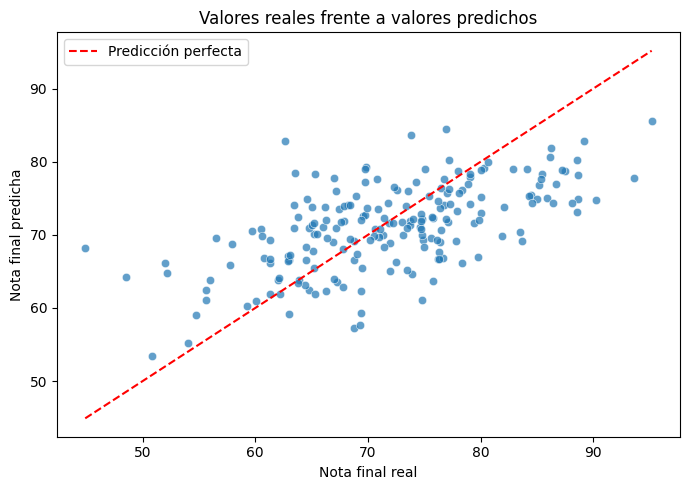

In [28]:
# Comparación visual de las notas reales y las notas predichas
graficar_reales_predichos(
    y_test_reg,
    y_pred_reg
)


### Valores reales frente a valores predichos

El gráfico muestra una relación positiva entre las notas reales y las notas estimadas. En general, cuando aumenta la nota real también aumenta la predicción del modelo.

Sin embargo, las predicciones se encuentran más concentradas en valores intermedios que las notas reales. Esta concentración provoca que el modelo tienda a sobreestimar algunas notas bajas y a subestimar algunas notas altas.

Los puntos correspondientes a notas intermedias aparecen, en general, más próximos a la línea de predicción perfecta. En cambio, la separación respecto a esta línea aumenta en algunos valores situados en los extremos.

Por tanto, el modelo recoge una parte de la tendencia general, pero presenta más dificultades para reproducir correctamente las notas especialmente bajas o altas.

### 8.8 Análisis de residuos

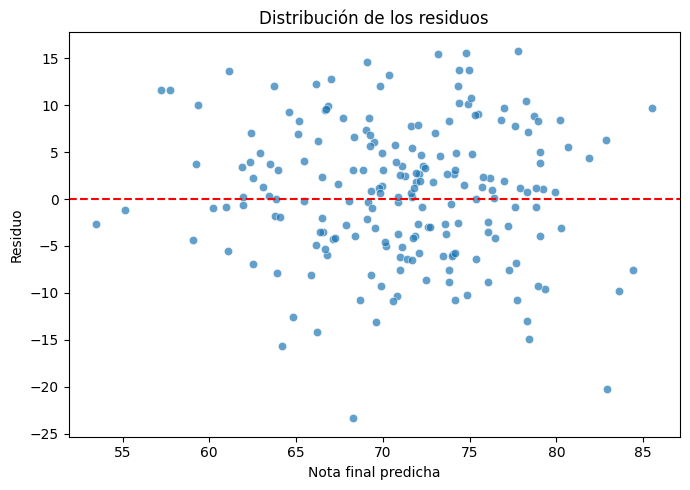

In [29]:
# Visualización de los errores del modelo
graficar_residuos(
    y_test_reg,
    y_pred_reg
)

### Análisis de residuos

Los residuos se distribuyen tanto por encima como por debajo de cero, lo que indica que el modelo comete errores en las dos direcciones: en algunos casos subestima la nota final y en otros la sobreestima.

Una parte importante de los residuos se concentra alrededor de cero, aunque también se observan varios errores de mayor magnitud. Destaca algún residuo negativo alejado del resto, correspondiente a un caso en el que el modelo estimó una nota notablemente superior a la nota real.

La dispersión de los residuos confirma que el ajuste no es perfecto y que existen diferencias relevantes entre algunas notas reales y predichas. Además, el modelo parece tender hacia valores intermedios, lo que dificulta la estimación de determinados casos situados en los extremos.

Aunque no se aprecia una forma curva claramente definida, la dispersión observada aconseja interpretar el modelo como una primera aproximación lineal al problema.

### 8.9 Evaluación en entrenamiento y prueba

In [30]:
# Predicciones sobre el conjunto de entrenamiento
y_pred_train_reg = pipeline_regresion.predict(X_train_reg)

# Evaluación en entrenamiento
metricas_regresion_train = evaluar_regresion(
    y_train_reg,
    y_pred_train_reg
)

metricas_regresion_train["valor"] = metricas_regresion_train["valor"].round(3)

# Comparación de métricas entre entrenamiento y prueba
comparacion_train_test_reg = pd.DataFrame({
    "metrica": metricas_regresion_train["metrica"],
    "entrenamiento": metricas_regresion_train["valor"],
    "prueba": metricas_regresion_test["valor"]
})

comparacion_train_test_reg

,metrica,entrenamiento,prueba
0,MAE,6.029,5.816
1,RMSE,7.550,7.247
2,R2,0.392,0.358


### Comparación entre entrenamiento y prueba

Los resultados obtenidos en entrenamiento y prueba son bastante similares, lo que indica que el modelo mantiene un comportamiento estable al trabajar con datos que no se utilizaron durante el ajuste.

En el conjunto de entrenamiento se obtiene un MAE de 6,029 puntos y un RMSE de 7,550 puntos. En el conjunto de prueba, estas métricas son ligeramente inferiores, con un MAE de 5,816 y un RMSE de 7,247 puntos.

Aunque lo habitual es obtener errores algo menores en entrenamiento, esta pequeña diferencia no resulta preocupante. Puede deberse a que la partición de prueba contiene algunos registros más sencillos de predecir o presenta una distribución ligeramente más favorable para el modelo.

El coeficiente R² es de 0,392 en entrenamiento y de 0,358 en prueba. La diferencia entre ambos valores es reducida, ya que el modelo explica aproximadamente el 39,2% de la variabilidad en entrenamiento y el 35,8% en prueba.

En conjunto, no se observan indicios claros de sobreajuste. El modelo ofrece un rendimiento parecido en ambos conjuntos, aunque su capacidad explicativa es moderada y una parte importante de la variabilidad de `nota_final` sigue sin quedar explicada.

### 8.10 Conclusiones del modelo de regresión lineal

El modelo de regresión lineal se ha entrenado mediante un pipeline que integra el escalado de las variables numéricas, la codificación de las variables categóricas y el ajuste del modelo. De esta forma, todas las transformaciones se aplican dentro del mismo proceso y se evita utilizar información del conjunto de prueba durante el entrenamiento.

En el conjunto de prueba, el modelo obtiene un MAE de 5,816 puntos. Esto significa que, por término medio, la diferencia absoluta entre la nota real y la nota estimada es de aproximadamente 5,8 puntos.

El RMSE alcanza un valor de 7,247 puntos. Al ser superior al MAE, esta métrica indica que existen algunos casos con errores de predicción más elevados que el error medio.

El coeficiente R² es de 0,358, por lo que el modelo explica aproximadamente el 35,8% de la variabilidad observada en `nota_final`. El modelo consigue recoger una parte de la relación entre las variables predictoras y la nota final, aunque todavía queda una proporción considerable de la variabilidad sin explicar.

La comparación con el modelo de referencia muestra que la regresión lineal proporciona mejores resultados. El MAE disminuye de 7,248 a 5,816 puntos y el RMSE pasa de 9,057 a 7,247 puntos. Además, el modelo de referencia obtiene un R² de -0,003, mientras que la regresión lineal alcanza un valor de 0,358. Por tanto, las variables predictoras aportan información útil para estimar la nota final.

En la comparación visual entre valores reales y predichos se observa que el modelo recoge la tendencia general de los datos, pero concentra buena parte de las predicciones en notas intermedias. Esto provoca que algunas notas bajas sean sobreestimadas y que algunas notas altas sean subestimadas. Por tanto, el modelo presenta más dificultades para reproducir correctamente los valores situados en los extremos.

El análisis de residuos muestra errores tanto positivos como negativos, por lo que el modelo comete desviaciones en las dos direcciones. La mayoría de los residuos se encuentra alrededor de cero, aunque también aparecen algunos casos con errores de mayor magnitud. No se observa una forma curva claramente definida, pero la dispersión confirma que el ajuste lineal no consigue representar completamente todos los casos del dataset.

Por último, los resultados obtenidos en entrenamiento y prueba son parecidos. El R² pasa de 0,392 en entrenamiento a 0,358 en prueba, mientras que las diferencias en MAE y RMSE son reducidas. Esta estabilidad indica que no se observan señales claras de sobreajuste y que el modelo mantiene un comportamiento similar con datos no utilizados durante el entrenamiento.

En conjunto, la regresión lineal mejora claramente una predicción basada únicamente en la media y ofrece una primera aproximación útil para estimar `nota_final`. Sin embargo, su capacidad explicativa es moderada y los resultados indican que podrían existir otros factores no incluidos en el dataset, relaciones no lineales o interacciones entre variables que también influyen en la nota final.

## 9. Modelo de regresión logística

En este apartado se construye un modelo de regresión logística para predecir la variable `aprobado`.

La variable objetivo toma el valor 1 cuando el estudiante ha aprobado y el valor 0 cuando no ha aprobado.

Durante el análisis exploratorio se observó que las clases se encuentran desequilibradas, ya que la mayoría de estudiantes pertenece a la clase de aprobado. Por este motivo, el rendimiento del modelo no se valorará únicamente mediante el accuracy.

Además del porcentaje global de aciertos, se revisará cómo se comporta el modelo con cada una de las clases mediante precision, recall, f1-score y la matriz de confusión.

### 9.1 Creación del pipeline de clasificación

In [31]:
# Creación del pipeline para el modelo inicial de regresión logística
pipeline_clasificacion = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        (
            "modelo",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Mostramos la estructura del pipeline
pipeline_clasificacion

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

### Creación del pipeline de clasificación

El pipeline de clasificación combina el preprocesamiento de las variables con el modelo de regresión logística.

Las variables numéricas se escalan y las categóricas se transforman mediante One-Hot Encoding antes de entrar en el modelo.

Se establece `max_iter=1000` para proporcionar al algoritmo suficientes iteraciones para alcanzar la convergencia. También se utiliza `random_state=42` para mantener la reproducibilidad del proceso.

### 9.2 Entranamiento del modelo inicial

In [32]:
# Entrenamiento del modelo inicial de regresión logística
pipeline_clasificacion.fit(
    X_train_clf,
    y_train_clf
)

print("Modelo inicial de regresión logística entrenado correctamente.")

Modelo inicial de regresión logística entrenado correctamente.


### Entrenamiento del modelo inicial

El pipeline se entrena utilizando el conjunto de entrenamiento del problema de clasificación.

Durante este proceso se ajustan las transformaciones utilizando únicamente los datos de entrenamiento y, a continuación, se entrena el modelo de regresión logística.

En esta primera versión no se aplica ningún ajuste específico para compensar el desequilibrio entre clases. El objetivo es obtener un resultado inicial que sirva como referencia antes de probar una versión balanceada.

### 9.3 Predicciones sobre el conjunto de prueba

In [33]:
# Predicciones de clase sobre el conjunto de prueba
y_pred_clf = pipeline_clasificacion.predict(
    X_test_clf
)

# Mostramos las primeras predicciones
y_pred_clf[:20]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1])

In [34]:
# Comprobación del número de valores reales y predicciones
print("Número de valores reales:", y_test_clf.shape[0])
print("Número de predicciones:", y_pred_clf.shape[0])

Número de valores reales: 200
Número de predicciones: 200


### Predicciones del modelo

Una vez entrenado el modelo, se realizan predicciones sobre los 200 registros del conjunto de prueba.

Cada predicción toma el valor 0 o 1, dependiendo de si el modelo estima que el estudiante no aprobará o aprobará.

El número de predicciones coincide con el número de registros del conjunto de prueba, por lo que se puede continuar con la evaluación.

### 9.4 Recargar e importar las nuevas funciones 

In [35]:
# Recargamos el módulo después de añadir las funciones de clasificación
import importlib
import src.model_utils as model_utils

importlib.reload(model_utils)

from src.model_utils import (
    evaluar_regresion,
    graficar_reales_predichos,
    graficar_residuos,
    evaluar_clasificacion,
    graficar_matriz_confusion,
    obtener_informe_clasificacion
)


### Importación de las funciones de clasificación

El archivo `model_utils.py` se ha ampliado con funciones para evaluar el modelo de clasificación, representar la matriz de confusión y obtener las métricas de cada clase.

Como el módulo ya se había utilizado durante la regresión, se recarga para incorporar las nuevas funciones sin reiniciar el kernel del notebook.

### 9.5 Evaluación del modelo inicial

In [36]:
# Evaluación del modelo inicial sobre el conjunto de prueba
metricas_clasificacion = evaluar_clasificacion(
    y_test_clf,
    y_pred_clf
)

# Redondeamos las métricas para facilitar su lectura
metricas_clasificacion["valor"] = (
    metricas_clasificacion["valor"].round(3)
)

metricas_clasificacion

,metrica,valor
0,Accuracy,0.895
1,Balanced accuracy,0.564
2,Precision no aprobado,0.429
3,Recall no aprobado,0.150
4,F1 no aprobado,0.222


### Evaluación del modelo inicial

La evaluación incluye el accuracy global y el balanced accuracy, que calcula el promedio del recall obtenido en las dos clases.

También se calculan precision, recall y f1-score para la clase `No aprobado`, ya que es la clase menos representada y la más fácil de ignorar en un dataset desequilibrado.

Un accuracy elevado no será suficiente para considerar que el modelo funciona correctamente. También será necesario comprobar si consigue detectar una parte razonable de los estudiantes no aprobados.

### 9.6 Matriz de confusión

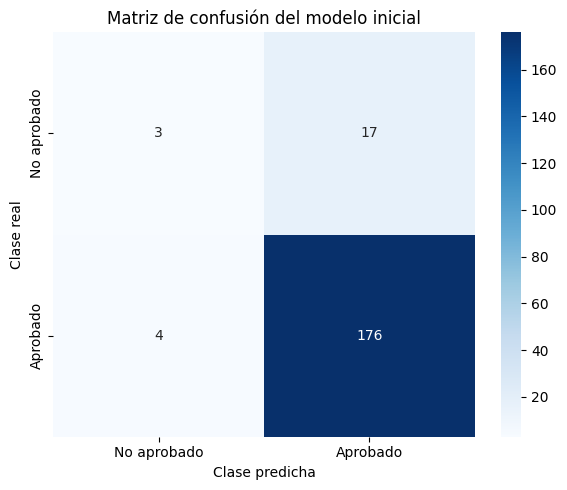

In [37]:
# Matriz de confusión del modelo inicial
graficar_matriz_confusion(
    y_test_clf,
    y_pred_clf,
    titulo="Matriz de confusión del modelo inicial"
)

### Matriz de confusión

La matriz de confusión permite observar cuántos estudiantes de cada clase han sido clasificados correctamente y qué tipo de errores ha cometido el modelo.

Las filas representan las clases reales y las columnas las clases predichas.

En este caso, resulta especialmente importante revisar cuántos estudiantes no aprobados han sido identificados correctamente y cuántos han sido clasificados de forma incorrecta como aprobados.

### 9.7 Informe de clasificación por clase

In [38]:
# Informe de clasificación para cada clase
informe_clasificacion = obtener_informe_clasificacion(
    y_test_clf,
    y_pred_clf
)

informe_clasificacion.round(3)

,precision,recall,f1-score,support
No aprobado,0.429,0.150,0.222,20.000
Aprobado,0.912,0.978,0.944,180.000
accuracy,0.895,0.895,0.895,0.895
macro avg,0.670,0.564,0.583,200.000
weighted avg,0.864,0.895,0.872,200.000


### 9.8 Interpretación del modelo inicial

El modelo inicial obtiene un accuracy de 0,895, por lo que clasifica correctamente el 89,5% de los registros del conjunto de prueba.

A primera vista, este resultado podría parecer elevado. Sin embargo, debe interpretarse teniendo en cuenta que el 90% de los estudiantes del conjunto de prueba pertenece a la clase `Aprobado`.

La matriz de confusión muestra que el modelo clasifica correctamente a 176 de los 180 estudiantes aprobados. En cambio, solo identifica correctamente a 3 de los 20 estudiantes no aprobados y clasifica los 17 restantes como aprobados.

Este comportamiento también se refleja en el recall de la clase `No aprobado`, que alcanza únicamente un valor de 0,150. Por tanto, el modelo solo detecta el 15% de los estudiantes que realmente no han aprobado.

La precision de esta clase es de 0,429. Esto significa que, entre los estudiantes clasificados por el modelo como no aprobados, el 42,9% pertenece realmente a esa clase.

El f1-score de los no aprobados es de 0,222, lo que confirma que el comportamiento del modelo con la clase minoritaria es limitado.

El balanced accuracy alcanza un valor de 0,564, muy inferior al accuracy global. Esta diferencia muestra que el buen resultado general está condicionado principalmente por la capacidad del modelo para predecir la clase mayoritaria.

En conjunto, el modelo inicial identifica correctamente a casi todos los estudiantes aprobados, pero presenta muchas dificultades para detectar a los no aprobados. Por este motivo, no parece suficiente valorar el modelo únicamente a partir del accuracy y resulta conveniente probar una versión que tenga en cuenta el desequilibrio entre clases.

### 9.9 Comparación con un modelo de referencia

In [39]:
# Modelo de referencia: predecir siempre la clase mayoritaria
prediccion_mayoritaria = np.ones(
    shape=y_test_clf.shape[0],
    dtype=int
)

# Evaluación del modelo de referencia
metricas_referencia_clf = evaluar_clasificacion(
    y_test_clf,
    prediccion_mayoritaria
)

metricas_referencia_clf["valor"] = (
    metricas_referencia_clf["valor"].round(3)
)

metricas_referencia_clf

,metrica,valor
0,Accuracy,0.9
1,Balanced accuracy,0.5
2,Precision no aprobado,0.0
3,Recall no aprobado,0.0
4,F1 no aprobado,0.0


In [40]:
# Comparación entre el modelo inicial y el modelo de referencia
comparacion_inicial_referencia = pd.DataFrame({
    "metrica": metricas_clasificacion["metrica"],
    "modelo_inicial": metricas_clasificacion["valor"],
    "modelo_referencia": metricas_referencia_clf["valor"]
})

comparacion_inicial_referencia

,metrica,modelo_inicial,modelo_referencia
0,Accuracy,0.895,0.9
1,Balanced accuracy,0.564,0.5
2,Precision no aprobado,0.429,0.0
3,Recall no aprobado,0.150,0.0
4,F1 no aprobado,0.222,0.0


### Comparación con un modelo de referencia

El modelo de referencia clasifica a todos los estudiantes como aprobados, ya que esta es la clase mayoritaria del conjunto de prueba.

Esta estrategia obtiene un accuracy de 0,900, ligeramente superior al 0,895 alcanzado por la regresión logística inicial. Sin embargo, este resultado se debe al desequilibrio de la variable objetivo y no a una capacidad real para distinguir entre las dos clases.

El modelo de referencia no identifica a ningún estudiante no aprobado. Por este motivo, obtiene valores de cero en precision, recall y f1-score para esta clase. Su balanced accuracy también se queda en 0,500, resultado equivalente al comportamiento de una clasificación que solo reconoce una de las dos clases.

La regresión logística inicial obtiene un accuracy ligeramente inferior, pero consigue identificar 3 de los 20 estudiantes no aprobados. Esto permite alcanzar un recall de 0,150 y un f1-score de 0,222 para la clase minoritaria.

El balanced accuracy del modelo inicial aumenta hasta 0,564, frente al 0,500 del modelo de referencia. Esto indica que la regresión logística utiliza parte de la información de las variables predictoras y consigue distinguir entre las clases mejor que la estrategia mayoritaria.

Aun así, la mejora sigue siendo limitada, ya que 17 de los 20 estudiantes no aprobados se clasifican incorrectamente como aprobados. Por tanto, resulta necesario probar una versión balanceada del modelo para intentar mejorar la detección de la clase minoritaria.

### 9.10 Modelo de regresión logística balanceado

In [41]:
class_weight="balanced"


### Modelo de regresión logística balanceado

Debido al bajo rendimiento del modelo inicial con los estudiantes no aprobados, se entrena una segunda regresión logística utilizando `class_weight="balanced"`.

Este ajuste asigna un peso mayor a la clase menos representada durante el entrenamiento. El objetivo es que el modelo preste más atención a los estudiantes no aprobados y mejore su capacidad para identificarlos.

Es posible que esta mejora reduzca el accuracy global o aumente el número de estudiantes aprobados clasificados incorrectamente. Por este motivo, la elección del modelo final se realizará comparando varias métricas y las matrices de confusión.

### 9.10.1 Creación del pipeline balanceado

In [42]:
# Creación del pipeline de regresión logística balanceada
pipeline_clasificacion_balanceado = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        (
            "modelo",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

pipeline_clasificacion_balanceado

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

### 9.10.2 Entrenar el modelo

In [43]:
# Entrenamiento del modelo balanceado
pipeline_clasificacion_balanceado.fit(
    X_train_clf,
    y_train_clf
)

print("Modelo de regresión logística balanceado entrenado correctamente.")

Modelo de regresión logística balanceado entrenado correctamente.


### Entrenar el modelo

El modelo balanceado utiliza las mismas variables, la misma división train-test y las mismas transformaciones que el modelo inicial.

La única diferencia es la incorporación de pesos de clase durante el entrenamiento. De esta forma, la comparación entre los dos modelos se centra en el efecto de compensar el desequilibrio.

### 9.11 Predicciones y evaluación del modelo balanceado

In [44]:
# Predicciones del modelo balanceado sobre el conjunto de prueba
y_pred_clf_balanceado = pipeline_clasificacion_balanceado.predict(
    X_test_clf
)

print("Número de predicciones:", y_pred_clf_balanceado.shape[0])

Número de predicciones: 200


In [45]:
# Evaluación del modelo balanceado
metricas_clasificacion_balanceado = evaluar_clasificacion(
    y_test_clf,
    y_pred_clf_balanceado
)

metricas_clasificacion_balanceado["valor"] = (
    metricas_clasificacion_balanceado["valor"].round(3)
)

metricas_clasificacion_balanceado

,metrica,valor
0,Accuracy,0.700
1,Balanced accuracy,0.656
2,Precision no aprobado,0.188
3,Recall no aprobado,0.600
4,F1 no aprobado,0.286


### Evaluación del modelo balanceado

El modelo balanceado obtiene un accuracy de 0,700, inferior al 0,895 alcanzado por el modelo inicial. Esta reducción indica que el número total de predicciones correctas ha disminuido después de aplicar los pesos de clase.

Sin embargo, el balanced accuracy aumenta de 0,564 a 0,656. Esta métrica tiene en cuenta el rendimiento obtenido en las dos clases y muestra que el modelo balanceado presenta un comportamiento más equilibrado entre estudiantes aprobados y no aprobados.

La principal mejora aparece en el recall de la clase `No aprobado`, que pasa de 0,150 a 0,600. El modelo balanceado consigue identificar correctamente al 60% de los estudiantes que realmente no han aprobado, frente al 15% detectado por el modelo inicial.

La precision de esta clase disminuye de 0,429 a 0,188. Esto significa que, entre todos los estudiantes clasificados como no aprobados por el modelo balanceado, únicamente el 18,8% pertenece realmente a esa clase.

El f1-score de los no aprobados aumenta ligeramente de 0,222 a 0,286. Aunque sigue siendo un valor reducido, esta mejora indica que el aumento del recall compensa parcialmente la pérdida de precision.

En conjunto, el modelo balanceado detecta una proporción mucho mayor de estudiantes no aprobados, pero genera también un número elevado de falsos avisos sobre estudiantes que realmente han aprobado.

### 9.12 Matriz de confusión del modelo balanceado

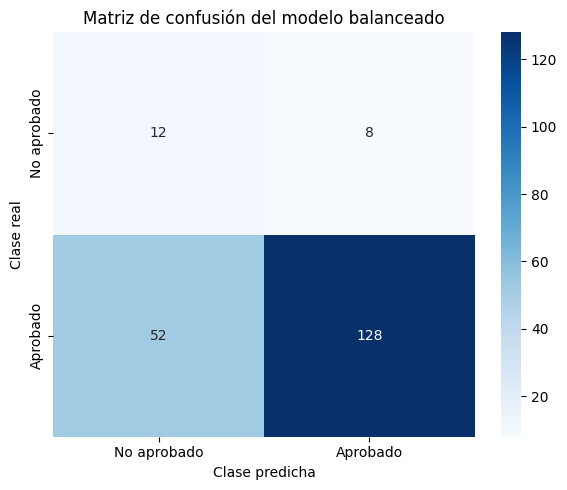

In [46]:
# Matriz de confusión del modelo balanceado
graficar_matriz_confusion(
    y_test_clf,
    y_pred_clf_balanceado,
    titulo="Matriz de confusión del modelo balanceado"
)

### Matriz de confusión del modelo balanceado

La matriz de confusión muestra que el modelo balanceado identifica correctamente a 12 de los 20 estudiantes no aprobados. Los 8 restantes se clasifican incorrectamente como aprobados.

Esta detección mejora claramente respecto al modelo inicial, que solo conseguía identificar correctamente a 3 estudiantes no aprobados.

Por otro lado, el modelo balanceado clasifica correctamente a 128 de los 180 estudiantes aprobados, mientras que 52 estudiantes aprobados se clasifican de forma incorrecta como no aprobados.

Por tanto, el ajuste de pesos consigue que el modelo preste más atención a la clase minoritaria, pero esta mejora produce un aumento considerable de falsos positivos para la clase `No aprobado`.

Nota: Falso positivo de No aprobado = estudiante predicho como no aprobado que realmente aprobó

### 9.13 Informe de clasificación del modelo balanceado

In [47]:
# Informe de clasificación del modelo balanceado
informe_clasificacion_balanceado = obtener_informe_clasificacion(
    y_test_clf,
    y_pred_clf_balanceado
)

informe_clasificacion_balanceado.round(3)

,precision,recall,f1-score,support
No aprobado,0.188,0.600,0.286,20.0
Aprobado,0.941,0.711,0.810,180.0
accuracy,0.700,0.700,0.700,0.7
macro avg,0.564,0.656,0.548,200.0
weighted avg,0.866,0.700,0.758,200.0


#### Informe de clasificación del modelo balanceado

El informe de clasificación confirma que el ajuste de pesos cambia de forma importante el comportamiento del modelo.

Para la clase `No aprobado`, el recall alcanza un valor de 0,600. Esto significa que el modelo consigue identificar a 6 de cada 10 estudiantes que realmente no han aprobado.

Sin embargo, la precision de esta clase es de 0,188. Por tanto, muchas de las predicciones de no aprobado corresponden en realidad a estudiantes aprobados. El f1-score se sitúa en 0,286, reflejando el desequilibrio entre un recall relativamente más alto y una precision baja.

En la clase `Aprobado`, la precision es de 0,941 y el recall de 0,711. El modelo mantiene una precision elevada al predecir aprobados, pero deja de identificar correctamente una parte de los estudiantes de esta clase.

El promedio macro de recall coincide con el balanced accuracy y alcanza un valor de 0,656. Este resultado es superior al obtenido por el modelo inicial y muestra un comportamiento menos condicionado por la clase mayoritaria.

### 9.14 Comparación directa entre modelos

In [48]:
# Comparación entre el modelo inicial y el modelo balanceado
comparacion_modelos_clasificacion = pd.DataFrame({
    "metrica": metricas_clasificacion["metrica"],
    "modelo_inicial": metricas_clasificacion["valor"],
    "modelo_balanceado": metricas_clasificacion_balanceado["valor"]
})

comparacion_modelos_clasificacion

,metrica,modelo_inicial,modelo_balanceado
0,Accuracy,0.895,0.700
1,Balanced accuracy,0.564,0.656
2,Precision no aprobado,0.429,0.188
3,Recall no aprobado,0.150,0.600
4,F1 no aprobado,0.222,0.286


### Comparación entre el modelo inicial y el modelo balanceado

La comparación muestra que los dos modelos presentan comportamientos diferentes.

El modelo inicial alcanza un accuracy de 0,895, mientras que el modelo balanceado obtiene un valor de 0,700. Por tanto, el modelo inicial consigue un mayor porcentaje global de aciertos.

Sin embargo, el balanced accuracy aumenta de 0,564 a 0,656 al aplicar los pesos de clase. Esto indica que el modelo balanceado reparte mejor su capacidad de clasificación entre aprobados y no aprobados.

La diferencia más importante aparece en el recall de la clase `No aprobado`, que pasa de 0,150 a 0,600. El modelo inicial identifica correctamente a 3 de los 20 estudiantes no aprobados, mientras que el modelo balanceado detecta a 12.

Esta mejora tiene un coste. La precision de los no aprobados disminuye de 0,429 a 0,188 porque el modelo balanceado clasifica como no aprobados a numerosos estudiantes que realmente han aprobado.

El f1-score de la clase minoritaria aumenta de 0,222 a 0,286. La mejora es moderada, ya que el aumento del recall queda limitado por la reducción de la precision.

Por tanto, el modelo inicial resulta más adecuado si la prioridad es maximizar el porcentaje total de predicciones correctas y evitar clasificar erróneamente a estudiantes aprobados. En cambio, el modelo balanceado resulta más apropiado si se considera más importante detectar a una proporción mayor de estudiantes con riesgo de no aprobar, aunque se generen más falsos avisos.

Dado el desequilibrio del dataset, el modelo balanceado ofrece una clasificación más sensible a la clase minoritaria, pero ninguno de los dos modelos presenta un rendimiento completamente satisfactorio con los estudiantes no aprobados.

### 9.15 Evaluación en entrenamiento y prueba

Para completar la evaluación, se compara el rendimiento de ambos modelos en los conjuntos de entrenamiento y prueba.

Esta comprobación permite observar si existe una diferencia importante entre los datos utilizados durante el ajuste y los datos reservados para la evaluación.

Debido al desequilibrio entre clases, la comparación se centrará principalmente en balanced accuracy, recall y f1-score para la clase `No aprobado`.

In [49]:
# Predicciones sobre entrenamiento con el modelo inicial
y_pred_train_clf = pipeline_clasificacion.predict(
    X_train_clf
)

# Predicciones sobre entrenamiento con el modelo balanceado
y_pred_train_clf_balanceado = (
    pipeline_clasificacion_balanceado.predict(
        X_train_clf
    )
)

In [50]:
# Evaluación del modelo inicial en entrenamiento
metricas_clasificacion_train = evaluar_clasificacion(
    y_train_clf,
    y_pred_train_clf
)

metricas_clasificacion_train["valor"] = (
    metricas_clasificacion_train["valor"].round(3)
)

# Evaluación del modelo balanceado en entrenamiento
metricas_clasificacion_balanceado_train = evaluar_clasificacion(
    y_train_clf,
    y_pred_train_clf_balanceado
)

metricas_clasificacion_balanceado_train["valor"] = (
    metricas_clasificacion_balanceado_train["valor"].round(3)
)

#### Modelo inicial

Se comparan las métricas del modelo inicial en entrenamiento y prueba para comprobar si mantiene un comportamiento similar con datos no utilizados durante el ajuste.

In [51]:
# Comparación entre entrenamiento y prueba del modelo inicial
comparacion_train_test_inicial = pd.DataFrame({
    "metrica": metricas_clasificacion_train["metrica"],
    "entrenamiento": metricas_clasificacion_train["valor"],
    "prueba": metricas_clasificacion["valor"]
})

comparacion_train_test_inicial

,metrica,entrenamiento,prueba
0,Accuracy,0.901,0.895
1,Balanced accuracy,0.567,0.564
2,Precision no aprobado,0.571,0.429
3,Recall no aprobado,0.146,0.150
4,F1 no aprobado,0.233,0.222


#### Modelo inicial

Los resultados del modelo inicial son bastante similares en entrenamiento y prueba.

El accuracy pasa de 0,901 en entrenamiento a 0,895 en prueba, mientras que el balanced accuracy únicamente disminuye de 0,567 a 0,564. Estas diferencias son mínimas y muestran que el rendimiento global se mantiene estable con datos no utilizados durante el ajuste.

El recall de la clase `No aprobado` también se mantiene prácticamente igual, con un valor de 0,146 en entrenamiento y de 0,150 en prueba. Esto confirma que la dificultad para detectar a los estudiantes no aprobados no aparece únicamente en el conjunto de prueba, sino que forma parte del comportamiento general del modelo.

La precision de esta clase disminuye de 0,571 a 0,429, aunque debe tenerse en cuenta que el número de estudiantes no aprobados es reducido y pequeños cambios en las predicciones pueden producir variaciones visibles en esta métrica.

El f1-score se mantiene en valores similares, pasando de 0,233 a 0,222.

En conjunto, no se observan señales claras de sobreajuste en el modelo inicial. El comportamiento es estable entre entrenamiento y prueba, pero sigue estando muy condicionado por la clase mayoritaria y presenta una capacidad limitada para identificar a los estudiantes no aprobados.

#### Modelo balanceado

Se realiza la misma comparación para el modelo balanceado, prestando especial atención a la estabilidad del recall y del f1-score de la clase `No aprobado`.

In [52]:
# Comparación entre entrenamiento y prueba del modelo balanceado
comparacion_train_test_balanceado = pd.DataFrame({
    "metrica": metricas_clasificacion_balanceado_train["metrica"],
    "entrenamiento": metricas_clasificacion_balanceado_train["valor"],
    "prueba": metricas_clasificacion_balanceado["valor"]
})

comparacion_train_test_balanceado

,metrica,entrenamiento,prueba
0,Accuracy,0.759,0.700
1,Balanced accuracy,0.758,0.656
2,Precision no aprobado,0.264,0.188
3,Recall no aprobado,0.756,0.600
4,F1 no aprobado,0.391,0.286


#### Modelo balanceado

El modelo balanceado presenta una diferencia mayor entre los resultados de entrenamiento y prueba.

El accuracy disminuye de 0,759 a 0,700, mientras que el balanced accuracy pasa de 0,758 en entrenamiento a 0,656 en prueba. Esta reducción indica que el comportamiento del modelo es menos estable que el observado en la versión inicial.

En la clase `No aprobado`, el recall disminuye de 0,756 a 0,600. Aun así, el valor obtenido en prueba sigue siendo claramente superior al recall de 0,150 alcanzado por el modelo inicial.

La precision de los no aprobados pasa de 0,264 en entrenamiento a 0,188 en prueba. Esto confirma que el modelo genera un número elevado de falsos avisos, especialmente al trabajar con datos no utilizados durante el ajuste.

El f1-score también disminuye, pasando de 0,391 a 0,286. Aunque el modelo balanceado mantiene una mejor capacidad para detectar estudiantes no aprobados que el modelo inicial, la diferencia entre entrenamiento y prueba muestra que su rendimiento es más sensible a la partición de los datos.

Estos resultados pueden indicar cierto grado de sobreajuste o variabilidad relacionado con el reducido número de estudiantes no aprobados. No obstante, una única división train-test no permite confirmarlo de forma definitiva, por lo que será conveniente completar el análisis mediante validación cruzada.

### 9.16 Conclusiones del modelo de clasificación

En este apartado se han entrenado y comparado dos modelos de regresión logística: un modelo inicial sin ajuste de clases y una segunda versión utilizando `class_weight="balanced"`.

El modelo inicial obtiene un accuracy de 0,895 en el conjunto de prueba. Sin embargo, este resultado está muy condicionado por el desequilibrio de la variable objetivo, ya que el 90% de los estudiantes del conjunto de prueba pertenece a la clase `Aprobado`.

La matriz de confusión muestra que el modelo inicial clasifica correctamente a 176 de los 180 estudiantes aprobados, pero solo identifica a 3 de los 20 estudiantes no aprobados. Como consecuencia, el recall de la clase `No aprobado` es únicamente de 0,150.

La comparación con una estrategia basada en predecir siempre la clase mayoritaria confirma que el accuracy no es suficiente para valorar este problema. El modelo de referencia obtiene un accuracy de 0,900, pero no identifica a ningún estudiante no aprobado. El modelo inicial consigue distinguir ligeramente mejor entre ambas clases, aunque su capacidad para detectar la clase minoritaria continúa siendo muy limitada.

Para intentar mejorar este comportamiento, se entrenó una segunda regresión logística con pesos balanceados. Este modelo reduce el accuracy hasta 0,700, pero aumenta el balanced accuracy de 0,564 a 0,656.

La principal mejora se observa en el recall de la clase `No aprobado`, que pasa de 0,150 a 0,600. El modelo balanceado identifica correctamente a 12 de los 20 estudiantes no aprobados, frente a los 3 detectados por el modelo inicial.

Esta mejora tiene un coste importante. La precision de los no aprobados disminuye de 0,429 a 0,188, ya que el modelo balanceado clasifica incorrectamente como no aprobados a 52 estudiantes que realmente han aprobado. Por tanto, muchas de sus predicciones de riesgo corresponden a falsos avisos.

El f1-score de la clase minoritaria mejora de 0,222 a 0,286. Aunque el incremento no es muy elevado, muestra que el aumento del recall compensa parcialmente la pérdida de precision.

La comparación entre entrenamiento y prueba indica que el modelo inicial mantiene un comportamiento muy estable, pero conserva las mismas dificultades para reconocer a los no aprobados en ambos conjuntos. El modelo balanceado presenta una reducción más visible de las métricas en el conjunto de prueba, especialmente en balanced accuracy, recall y f1-score. Esto indica que su comportamiento es menos estable y deberá revisarse mediante validación cruzada.

La elección entre ambos modelos depende del objetivo que se quiera priorizar. Si el objetivo principal fuera maximizar el número total de aciertos y evitar falsos avisos, el modelo inicial sería más adecuado. Sin embargo, si el modelo se utilizara como una herramienta de detección temprana de estudiantes con riesgo de no aprobar, el modelo balanceado sería más útil, ya que identifica una proporción considerablemente mayor de la clase minoritaria.

En este último caso, una predicción de `No aprobado` debería interpretarse como una señal para realizar una revisión adicional y no como una clasificación definitiva, debido a la baja precision obtenida.

En conjunto, el modelo balanceado resulta más sensible para detectar estudiantes con riesgo académico, pero ninguno de los dos modelos presenta un rendimiento completamente satisfactorio con la clase minoritaria. La validación cruzada permitirá comprobar si las diferencias observadas se mantienen en distintas particiones de los datos.

## 10. Validación cruzada

Hasta este punto, los modelos se han evaluado utilizando una única división entre entrenamiento y prueba.

Aunque esta división permite medir el rendimiento con datos no utilizados durante el ajuste, los resultados podrían depender de los registros incluidos en cada conjunto.

Para comprobar la estabilidad de los modelos, se aplica validación cruzada sobre los datos de entrenamiento. Este proceso divide los datos en varios grupos y repite el entrenamiento utilizando diferentes combinaciones.

El conjunto de prueba se mantiene fuera de este proceso, ya que debe conservarse como referencia final del rendimiento de los modelos.

### 10.1 Importación de herramientas

In [53]:
# Herramientas necesarias para la validación cruzada
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_validate
)

from sklearn.metrics import make_scorer

### Herramientas utilizadas

Para la regresión se utilizará `KFold`, que divide los datos de entrenamiento en varios grupos.

Para la clasificación se utilizará `StratifiedKFold`, ya que mantiene una proporción similar de aprobados y no aprobados en cada partición.

La función `cross_validate` permite evaluar varias métricas durante las distintas repeticiones del proceso.

### 10.2 Validación cruzada del modelo de regresión

Para validar el modelo de regresión se utiliza una estrategia de cinco particiones (5 folds)

Los datos se mezclan antes de crear los grupos y se mantiene `random_state=42` para que el proceso sea reproducible.

En cada repetición se calculan MAE, RMSE y R², las mismas métricas utilizadas anteriormente sobre el conjunto de prueba.

In [54]:
# Estrategia de validación cruzada para regresión
validacion_regresion = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [55]:
# Métricas utilizadas durante la validación cruzada de regresión
metricas_cv_regresion = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

In [56]:
# Validación cruzada del pipeline de regresión
resultados_cv_regresion = cross_validate(
    estimator=pipeline_regresion,
    X=X_train_reg,
    y=y_train_reg,
    cv=validacion_regresion,
    scoring=metricas_cv_regresion,
    n_jobs=-1
)

In [57]:
# Resultados de regresión obtenidos en cada partición
tabla_cv_regresion = pd.DataFrame({
    "particion": range(1, 6),
    "MAE": -resultados_cv_regresion["test_mae"],
    "RMSE": -resultados_cv_regresion["test_rmse"],
    "R2": resultados_cv_regresion["test_r2"]
})

tabla_cv_regresion.round(3)


,particion,MAE,RMSE,R2
0,1,6.281,8.190,0.306
1,2,6.015,7.709,0.359
2,3,6.081,7.378,0.342
3,4,5.869,7.257,0.407
4,5,6.746,8.170,0.376


#### Resultados por partición

La tabla muestra las métricas obtenidas en cada una de las cinco particiones.

Las diferencias entre particiones permiten observar si el rendimiento del modelo es estable o si cambia de forma importante según los registros utilizados para entrenar y validar.

### 10.3 Resumen de la validación de regresión

In [58]:
# Resumen de la validación cruzada del modelo de regresión
resumen_cv_regresion = pd.DataFrame({
    "metrica": ["MAE", "RMSE", "R2"],
    "media": [
        tabla_cv_regresion["MAE"].mean(),
        tabla_cv_regresion["RMSE"].mean(),
        tabla_cv_regresion["R2"].mean()
    ],
    "desviacion_estandar": [
        tabla_cv_regresion["MAE"].std(),
        tabla_cv_regresion["RMSE"].std(),
        tabla_cv_regresion["R2"].std()
    ]
})

resumen_cv_regresion.round(3)

,metrica,media,desviacion_estandar
0,MAE,6.198,0.340
1,RMSE,7.741,0.434
2,R2,0.358,0.038


### Resumen de la validación de regresión

La validación cruzada obtiene un MAE medio de 6,198 puntos y un RMSE medio de 7,741 puntos.

Las desviaciones estándar son de 0,340 para el MAE y de 0,434 para el RMSE. Estos valores indican que los errores no cambian de forma importante entre las cinco particiones y que el modelo mantiene un comportamiento relativamente estable.

El R² medio es de 0,358, con una desviación estándar de 0,038. Por tanto, el modelo explica, de media, aproximadamente el 35,8% de la variabilidad de `nota_final`.

Este resultado coincide con el R² de 0,358 obtenido anteriormente en el conjunto de prueba. La similitud entre ambas evaluaciones refuerza la idea de que el rendimiento observado no depende únicamente de la división inicial entre entrenamiento y prueba.

En conjunto, la validación cruzada confirma que la regresión lineal ofrece resultados estables, aunque su capacidad para explicar la variabilidad de la nota final continúa siendo moderada.

### 10.4 Métricas para la validación de clasificación

En la validación de los modelos de clasificación se calculan accuracy y balanced accuracy.

También se utilizan precision, recall y f1-score para la clase `No aprobado`, ya que esta es la clase minoritaria y la que presenta mayores dificultades de clasificación.

Para estas métricas se define de forma explícita el valor 0 como clase de interés.

In [59]:
# Métricas específicas para la clase No aprobado
scorer_precision_no_aprobado = make_scorer(
    precision_score,
    pos_label=0,
    zero_division=0
)

scorer_recall_no_aprobado = make_scorer(
    recall_score,
    pos_label=0,
    zero_division=0
)

scorer_f1_no_aprobado = make_scorer(
    f1_score,
    pos_label=0,
    zero_division=0
)

In [60]:
# Métricas utilizadas en la validación cruzada de clasificación
metricas_cv_clasificacion = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_no_aprobado": scorer_precision_no_aprobado,
    "recall_no_aprobado": scorer_recall_no_aprobado,
    "f1_no_aprobado": scorer_f1_no_aprobado
}

### 10.5 Estrategia estratificada de clasificación

In [61]:
# Estrategia de validación cruzada estratificada
validacion_clasificacion = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### Validación cruzada estratificada

Para los modelos de clasificación se utiliza una validación cruzada estratificada de cinco particiones.

La estratificación mantiene una proporción similar de aprobados y no aprobados en cada grupo. Esto es especialmente importante debido al desequilibrio de la variable objetivo.

### 10.6 Validación del modelo inicial

In [62]:
# Validación cruzada del modelo inicial
resultados_cv_clf_inicial = cross_validate(
    estimator=pipeline_clasificacion,
    X=X_train_clf,
    y=y_train_clf,
    cv=validacion_clasificacion,
    scoring=metricas_cv_clasificacion,
    n_jobs=-1
)

In [63]:
# Resultados del modelo inicial en cada partición
tabla_cv_clf_inicial = pd.DataFrame({
    "particion": range(1, 6),
    "Accuracy": resultados_cv_clf_inicial["test_accuracy"],
    "Balanced accuracy": resultados_cv_clf_inicial["test_balanced_accuracy"],
    "Precision no aprobado": resultados_cv_clf_inicial["test_precision_no_aprobado"],
    "Recall no aprobado": resultados_cv_clf_inicial["test_recall_no_aprobado"],
    "F1 no aprobado": resultados_cv_clf_inicial["test_f1_no_aprobado"]
})

tabla_cv_clf_inicial.round(3)

,particion,Accuracy,Balanced accuracy,Precision no aprobado,Recall no aprobado,F1 no aprobado
0,1,0.894,0.524,0.333,0.062,0.105
1,2,0.906,0.587,0.600,0.188,0.286
2,3,0.906,0.531,1.000,0.062,0.118
3,4,0.875,0.567,0.333,0.176,0.231
4,5,0.894,0.578,0.500,0.176,0.261


### Validación del modelo inicial por partición

El modelo inicial mantiene un accuracy elevado en todas las particiones, con valores comprendidos entre 0,875 y 0,906.

Sin embargo, el recall de la clase `No aprobado` se mantiene en valores bajos, entre 0,062 y 0,188. Esto significa que, dependiendo de la partición, el modelo solo identifica entre el 6,2% y el 18,8% de los estudiantes no aprobados.

El balanced accuracy también permanece próximo a 0,5, con valores entre 0,524 y 0,587. Por tanto, el rendimiento elevado en accuracy continúa estando condicionado principalmente por la clasificación de los estudiantes aprobados.

Los resultados confirman que la dificultad del modelo inicial para detectar la clase minoritaria no se debe únicamente a la división train-test utilizada anteriormente, sino que aparece de forma repetida en las distintas particiones.
`

### 10.7 Validación del modelo balanceado

In [64]:
# Validación cruzada del modelo balanceado
resultados_cv_clf_balanceado = cross_validate(
    estimator=pipeline_clasificacion_balanceado,
    X=X_train_clf,
    y=y_train_clf,
    cv=validacion_clasificacion,
    scoring=metricas_cv_clasificacion,
    n_jobs=-1
)

In [65]:
# Resultados del modelo balanceado en cada partición
tabla_cv_clf_balanceado = pd.DataFrame({
    "particion": range(1, 6),
    "Accuracy": resultados_cv_clf_balanceado["test_accuracy"],
    "Balanced accuracy": resultados_cv_clf_balanceado["test_balanced_accuracy"],
    "Precision no aprobado": resultados_cv_clf_balanceado["test_precision_no_aprobado"],
    "Recall no aprobado": resultados_cv_clf_balanceado["test_recall_no_aprobado"],
    "F1 no aprobado": resultados_cv_clf_balanceado["test_f1_no_aprobado"]
})

tabla_cv_clf_balanceado.round(3)

,particion,Accuracy,Balanced accuracy,Precision no aprobado,Recall no aprobado,F1 no aprobado
0,1,0.744,0.719,0.234,0.688,0.349
1,2,0.756,0.670,0.220,0.562,0.316
2,3,0.762,0.729,0.250,0.688,0.367
3,4,0.762,0.763,0.277,0.765,0.406
4,5,0.775,0.770,0.289,0.765,0.419


### Validación del modelo balanceado por partición

El modelo balanceado obtiene un accuracy inferior al modelo inicial, con valores comprendidos entre 0,744 y 0,775.

A cambio, el balanced accuracy alcanza valores entre 0,670 y 0,770, claramente superiores a los obtenidos por el modelo inicial. Esto indica que el modelo balanceado reparte mejor su capacidad de clasificación entre las dos clases.

El recall de la clase `No aprobado` se sitúa entre 0,562 y 0,765. Por tanto, en todas las particiones el modelo consigue identificar una proporción considerablemente mayor de estudiantes no aprobados.

La precision de esta clase sigue siendo baja, con valores comprendidos entre 0,220 y 0,289. Esto confirma que la mejora en la detección de no aprobados continúa acompañada de un número elevado de falsos avisos.

A pesar de esta limitación, el f1-score de la clase minoritaria se mantiene entre 0,316 y 0,419, por encima de los resultados obtenidos por el modelo inicial en la mayoría de las particiones.

### 10.8 Resumen comparativo de clasificación 

In [66]:
# Resumen medio del modelo inicial
media_cv_clf_inicial = pd.Series({
    "Accuracy": resultados_cv_clf_inicial["test_accuracy"].mean(),
    "Balanced accuracy": resultados_cv_clf_inicial["test_balanced_accuracy"].mean(),
    "Precision no aprobado": resultados_cv_clf_inicial["test_precision_no_aprobado"].mean(),
    "Recall no aprobado": resultados_cv_clf_inicial["test_recall_no_aprobado"].mean(),
    "F1 no aprobado": resultados_cv_clf_inicial["test_f1_no_aprobado"].mean()
})

# Resumen medio del modelo balanceado
media_cv_clf_balanceado = pd.Series({
    "Accuracy": resultados_cv_clf_balanceado["test_accuracy"].mean(),
    "Balanced accuracy": resultados_cv_clf_balanceado["test_balanced_accuracy"].mean(),
    "Precision no aprobado": resultados_cv_clf_balanceado["test_precision_no_aprobado"].mean(),
    "Recall no aprobado": resultados_cv_clf_balanceado["test_recall_no_aprobado"].mean(),
    "F1 no aprobado": resultados_cv_clf_balanceado["test_f1_no_aprobado"].mean()
})

# Tabla comparativa
comparacion_cv_clasificacion = pd.DataFrame({
    "modelo_inicial": media_cv_clf_inicial,
    "modelo_balanceado": media_cv_clf_balanceado
}).reset_index()

comparacion_cv_clasificacion.columns = [
    "metrica",
    "modelo_inicial",
    "modelo_balanceado"
]

comparacion_cv_clasificacion.round(3)

,metrica,modelo_inicial,modelo_balanceado
0,Accuracy,0.895,0.760
1,Balanced accuracy,0.557,0.730
2,Precision no aprobado,0.553,0.254
3,Recall no aprobado,0.133,0.693
4,F1 no aprobado,0.200,0.371


### Comparación de los modelos de clasificación

La validación cruzada confirma que los dos modelos responden a prioridades diferentes.

El modelo inicial obtiene un accuracy medio de 0,895, superior al 0,760 del modelo balanceado. Este resultado se debe principalmente a su capacidad para clasificar correctamente la clase mayoritaria.

Sin embargo, el balanced accuracy del modelo inicial es de 0,557, mientras que el modelo balanceado alcanza un valor medio de 0,730. Por tanto, el modelo balanceado presenta un comportamiento más equilibrado entre aprobados y no aprobados.

La diferencia más importante aparece en el recall de la clase `No aprobado`. El modelo inicial obtiene un valor medio de 0,133, por lo que únicamente identifica alrededor del 13,3% de los estudiantes no aprobados. El modelo balanceado eleva esta métrica hasta 0,693, identificando de media aproximadamente el 69,3% de los casos de la clase minoritaria.

La precision de los no aprobados disminuye de 0,553 en el modelo inicial a 0,254 en el balanceado. Esto indica que el modelo inicial realiza pocas predicciones de no aprobado, pero una mayor proporción de estas resulta correcta. El modelo balanceado detecta muchos más casos, aunque también genera más falsos avisos.

El f1-score medio de la clase minoritaria aumenta de 0,200 a 0,371. Esta mejora muestra que, a pesar de la pérdida de precision, el aumento del recall produce un comportamiento global más útil para detectar estudiantes con riesgo de no aprobar.

En conjunto, los resultados de validación cruzada mantienen el mismo patrón observado en el conjunto de prueba: el modelo inicial maximiza el porcentaje global de aciertos, mientras que el modelo balanceado ofrece una capacidad claramente superior para detectar la clase minoritaria.

### 10.9 Desviación estándar de los modelos 

In [67]:
# Desviación estándar del modelo inicial
std_cv_clf_inicial = pd.Series({
    "Accuracy": resultados_cv_clf_inicial["test_accuracy"].std(),
    "Balanced accuracy": resultados_cv_clf_inicial["test_balanced_accuracy"].std(),
    "Precision no aprobado": resultados_cv_clf_inicial["test_precision_no_aprobado"].std(),
    "Recall no aprobado": resultados_cv_clf_inicial["test_recall_no_aprobado"].std(),
    "F1 no aprobado": resultados_cv_clf_inicial["test_f1_no_aprobado"].std()
})

# Desviación estándar del modelo balanceado
std_cv_clf_balanceado = pd.Series({
    "Accuracy": resultados_cv_clf_balanceado["test_accuracy"].std(),
    "Balanced accuracy": resultados_cv_clf_balanceado["test_balanced_accuracy"].std(),
    "Precision no aprobado": resultados_cv_clf_balanceado["test_precision_no_aprobado"].std(),
    "Recall no aprobado": resultados_cv_clf_balanceado["test_recall_no_aprobado"].std(),
    "F1 no aprobado": resultados_cv_clf_balanceado["test_f1_no_aprobado"].std()
})

comparacion_std_clasificacion = pd.DataFrame({
    "modelo_inicial": std_cv_clf_inicial,
    "modelo_balanceado": std_cv_clf_balanceado
}).reset_index()

comparacion_std_clasificacion.columns = [
    "metrica",
    "modelo_inicial",
    "modelo_balanceado"
]

comparacion_std_clasificacion.round(3)

,metrica,modelo_inicial,modelo_balanceado
0,Accuracy,0.011,0.010
1,Balanced accuracy,0.025,0.036
2,Precision no aprobado,0.245,0.026
3,Recall no aprobado,0.058,0.074
4,F1 no aprobado,0.075,0.038


### Desviación estándar de los modelos 

Las desviaciones estándar de accuracy son reducidas en ambos modelos, con valores de 0,011 para el modelo inicial y 0,010 para el balanceado. Esto indica que el porcentaje global de aciertos se mantiene estable entre las distintas particiones.

El balanced accuracy también presenta una variabilidad moderada, aunque ligeramente superior en el modelo balanceado, con una desviación de 0,036 frente a 0,025 en el modelo inicial.

La mayor diferencia aparece en la precision de la clase `No aprobado`. El modelo inicial presenta una desviación estándar de 0,245, mientras que en el balanceado es de 0,026. Esta elevada variabilidad se debe a que el modelo inicial predice muy pocos casos como no aprobados, por lo que pequeños cambios en el número de aciertos producen grandes variaciones en la precision.

El recall de los no aprobados presenta desviaciones de 0,058 en el modelo inicial y 0,074 en el balanceado. Aunque el balanceado muestra algo más de variación en esta métrica, mantiene valores claramente superiores en todas las particiones.

El f1-score de la clase minoritaria presenta una desviación de 0,075 en el modelo inicial y de 0,038 en el balanceado. Por tanto, el equilibrio entre precision y recall resulta más estable en la versión con pesos de clase.

En general, el modelo balanceado mantiene de forma consistente una mayor capacidad para detectar estudiantes no aprobados, mientras que la precision del modelo inicial resulta especialmente sensible a la composición de cada partición.

### 10.10 Conclusiones de la validación cruzada

La validación cruzada se ha utilizado para comprobar si los resultados obtenidos anteriormente se mantienen al cambiar la composición de los conjuntos de entrenamiento y validación.

En el problema de regresión, el modelo obtiene un MAE medio de 6,198 puntos, un RMSE medio de 7,741 y un R² medio de 0,358. Las desviaciones estándar son reducidas, por lo que el rendimiento se mantiene relativamente estable entre las cinco particiones.

El R² medio coincide con el valor obtenido en el conjunto de prueba. Esto confirma que la regresión lineal explica aproximadamente el 35,8% de la variabilidad de `nota_final` y que este resultado no depende únicamente de la partición inicial de los datos.

En clasificación, el modelo inicial mantiene un accuracy medio elevado de 0,895, pero obtiene un balanced accuracy de 0,557 y un recall medio de solo 0,133 para la clase `No aprobado`. Por tanto, la validación cruzada confirma que este modelo presenta dificultades constantes para identificar a los estudiantes no aprobados.

El modelo balanceado reduce el accuracy medio hasta 0,760, pero aumenta el balanced accuracy a 0,730. Además, el recall medio de los no aprobados alcanza un valor de 0,693, frente al 0,133 del modelo inicial.

La precision media de los no aprobados disminuye hasta 0,254, lo que indica que el modelo balanceado sigue generando falsos avisos. Sin embargo, el f1-score de la clase minoritaria mejora de 0,200 a 0,371 y presenta una desviación estándar menor que en el modelo inicial.

Los resultados obtenidos en validación cruzada muestran que la pérdida de rendimiento observada en el conjunto de prueba del modelo balanceado estaba parcialmente condicionada por esa partición concreta. De media, el modelo balanceado alcanza resultados superiores a los obtenidos en el test en balanced accuracy, recall y f1-score.

En conjunto, la validación cruzada refuerza la elección del modelo balanceado cuando la prioridad es detectar estudiantes con riesgo de no aprobar. Aunque genera más falsos avisos y obtiene un accuracy global inferior, presenta una capacidad considerablemente mayor y relativamente estable para reconocer la clase minoritaria.

La regresión logística inicial sería más adecuada si se quisiera maximizar el número total de aciertos. Sin embargo, para utilizar el modelo como herramienta de detección temprana, la versión balanceada ofrece un comportamiento más útil, siempre que sus predicciones de no aprobado se interpreten como señales de alerta que requieren una revisión posterior.

## 11. Conclusiones generales del modelado

En este notebook se han entrenado y evaluado los dos modelos solicitados en el proyecto: una regresión lineal para predecir `nota_final` y una regresión logística para predecir la variable `aprobado`.

Para preparar los datos se ha utilizado un pipeline que aplica el escalado de las variables numéricas y la codificación One-Hot de las variables categóricas. Al incluir estas transformaciones dentro del pipeline, el preprocesamiento se ajusta únicamente con los datos de entrenamiento y se evita utilizar información del conjunto de prueba durante el aprendizaje.

### Modelo de regresión lineal

El modelo de regresión lineal obtiene un MAE de 5,816 puntos y un RMSE de 7,247 puntos en el conjunto de prueba. Esto significa que, por término medio, las predicciones se alejan aproximadamente 5,8 puntos de las notas reales, aunque existen algunos casos con errores de mayor magnitud.

El coeficiente R² alcanza un valor de 0,358, por lo que el modelo consigue explicar aproximadamente el 35,8% de la variabilidad de `nota_final`.

La comparación con una predicción básica basada en la nota media muestra que la regresión lineal aprovecha de forma útil la información de las variables predictoras. El modelo reduce tanto el MAE como el RMSE y mejora claramente el R² respecto al modelo de referencia.

La representación de valores reales y predichos muestra que el modelo recoge la tendencia general, pero concentra buena parte de las estimaciones en notas intermedias. Como consecuencia, algunas notas bajas se sobreestiman y algunas notas altas se subestiman.

Los resultados de entrenamiento y prueba son similares, con un R² de 0,392 en entrenamiento y de 0,358 en prueba. Esta diferencia reducida no muestra señales claras de sobreajuste.

La validación cruzada confirma esta estabilidad. El modelo obtiene un MAE medio de 6,198 puntos, un RMSE medio de 7,741 y un R² medio de 0,358. Las desviaciones entre particiones son reducidas, por lo que el resultado no parece depender únicamente de la división inicial de los datos.

En conjunto, la regresión lineal ofrece una primera aproximación útil y estable para estimar la nota final. Sin embargo, su capacidad explicativa es moderada, lo que indica que todavía existen factores no recogidos en el dataset o relaciones que un modelo lineal no consigue representar completamente.

### Modelo de regresión logística

En el problema de clasificación se ha tenido en cuenta el desequilibrio de la variable objetivo, ya que la mayoría de estudiantes pertenece a la clase `Aprobado`.

El modelo inicial obtiene un accuracy de 0,895 en el conjunto de prueba. No obstante, la matriz de confusión muestra que solo identifica correctamente a 3 de los 20 estudiantes no aprobados. El recall de esta clase es de 0,150, por lo que el modelo presenta muchas dificultades para reconocer la clase minoritaria.

La comparación con una estrategia que predice siempre la clase mayoritaria deja claro que el accuracy no es suficiente para evaluar este problema. El modelo de referencia alcanza un accuracy de 0,900, pero no identifica a ningún estudiante no aprobado.

Para compensar el desequilibrio se entrenó una segunda regresión logística utilizando `class_weight="balanced"`. Este modelo reduce el accuracy hasta 0,700, pero aumenta el balanced accuracy de 0,564 a 0,656.

La mejora más destacable aparece en el recall de la clase `No aprobado`, que pasa de 0,150 a 0,600. El modelo balanceado identifica correctamente a 12 de los 20 estudiantes no aprobados, frente a los 3 detectados por el modelo inicial.

Esta mejora tiene un coste. La precision de la clase minoritaria disminuye hasta 0,188, ya que el modelo balanceado clasifica como no aprobados a varios estudiantes que realmente han aprobado. Por tanto, consigue detectar más casos de riesgo, pero también genera un número elevado de falsos avisos.

La validación cruzada mantiene el mismo patrón. El modelo inicial obtiene un accuracy medio de 0,895, pero un recall medio de solo 0,133 para la clase `No aprobado`. El modelo balanceado reduce el accuracy medio a 0,760, aunque aumenta el balanced accuracy hasta 0,730 y el recall medio de los no aprobados hasta 0,693.

El f1-score medio de la clase minoritaria también mejora, pasando de 0,200 en el modelo inicial a 0,371 en el modelo balanceado. Estos resultados muestran que la versión balanceada presenta una capacidad mayor y más constante para reconocer a los estudiantes no aprobados.

### Selección del modelo de clasificación

La elección entre los dos modelos depende del objetivo que se quiera priorizar.

El modelo inicial sería más adecuado si el objetivo principal fuera maximizar el número total de predicciones correctas y evitar que estudiantes aprobados se clasifiquen como no aprobados. Sin embargo, esta versión apenas consigue identificar a los estudiantes de la clase minoritaria.

En cambio, el modelo balanceado resulta más útil si se pretende detectar de forma temprana estudiantes con posible riesgo de no aprobar. Aunque genera más falsos avisos y reduce el accuracy global, identifica una proporción considerablemente mayor de estudiantes no aprobados.

Teniendo en cuenta que en este proyecto interesa no ignorar a los estudiantes con riesgo de suspender, se considera más adecuada la regresión logística con `class_weight="balanced"`. Esta elección se basa principalmente en su mejor balanced accuracy, recall y f1-score para la clase minoritaria.

Las predicciones de `No aprobado` no deberían interpretarse como una decisión definitiva, sino como una señal de alerta que podría utilizarse para revisar cada caso con más información.

### Conclusión final

En general, los dos modelos permiten cumplir los objetivos planteados al inicio del proyecto. La regresión lineal consigue mejorar una predicción basada únicamente en la media, aunque todavía queda bastante variabilidad de la nota final sin explicar.

En clasificación, el principal problema ha sido el desequilibrio entre aprobados y no aprobados. El modelo inicial obtiene un accuracy alto, pero apenas detecta estudiantes no aprobados. Al utilizar pesos balanceados se consigue identificar una proporción mucho mayor de estos casos, aunque también aumentan los falsos avisos.

Por este motivo, considero más adecuado el modelo balanceado si se quiere utilizar como una herramienta de detección temprana. Sus predicciones no deberían tomarse como una decisión definitiva, sino como un aviso para revisar con más detalle determinados casos.

Como posibles mejoras, sería interesante disponer de más registros de estudiantes no aprobados, incluir nuevas variables relacionadas con el rendimiento académico y comparar estos resultados con otros modelos que puedan recoger relaciones no lineales.
